# HW03: Innovation Regression

Регрессионный анализ продаж и инновационных факторов.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as st
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 4)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
data_path = Path("data/innovation_new.xlsx")
raw_data = pd.read_excel(data_path)
raw_data.head()

,Sales,growth_technological,growth_marketing,share_RD,share_equipments,patents,cooperation,support,lab,joint,climate,share_technology,emp,growth_innovation,fin_support,age,compet
0,3.59,11.67,7.82,34.1,36.90,10,1,0,1,0,6,0.80,0.48,12.86,0.0000,43.0,0
1,1.28,2.34,4.70,27.1,16.56,1,0,0,0,0,10,0.02,0.46,2.29,0.0000,43.0,1
2,0.48,11.73,7.07,7.9,31.32,0,0,0,0,0,5,0.06,0.38,11.79,0.0000,35.0,837
3,0.86,9.01,3.91,19.0,16.29,3,0,0,0,0,5,0.31,0.10,8.95,0.0000,24.0,1
4,2.24,8.93,4.20,31.2,32.40,3,1,1,0,0,8,0.07,0.36,9.94,0.8974,39.0,0


In [3]:
data = raw_data.apply(pd.to_numeric, errors="coerce").dropna().copy()
target_name = "Sales"
feature_names = [column for column in data.columns if column != target_name]

x = data[feature_names]
y = data[target_name]

summary_table = data.describe().T
summary_table

,count,mean,std,min,25%,50%,75%,max
Sales,1000.0,1.9135,1.9809,0.13,0.7475,1.28,2.3225,24.0400
growth_technological,1000.0,6.8238,5.3400,0.09,3.3775,5.46,8.8050,52.1200
growth_marketing,1000.0,4.4538,1.3913,3.02,3.6700,4.08,4.6825,15.6100
share_RD,1000.0,24.9377,17.1896,-1.30,13.2000,20.70,32.0250,92.6548
share_equipments,1000.0,27.0537,18.3814,0.81,12.8475,22.86,37.3725,89.1000
patents,1000.0,1.6880,3.6038,0.00,0.0000,0.00,0.0000,19.0000
cooperation,1000.0,0.3410,0.4743,0.00,0.0000,0.00,1.0000,1.0000
support,1000.0,0.0070,0.0834,0.00,0.0000,0.00,0.0000,1.0000
lab,1000.0,0.2650,0.4416,0.00,0.0000,0.00,1.0000,1.0000
joint,1000.0,0.1410,0.3482,0.00,0.0000,0.00,0.0000,1.0000


In [4]:
x_with_constant = sm.add_constant(x)
full_model = sm.OLS(y, x_with_constant).fit()
full_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     281.8
Date:                Tue, 25 Aug 2026   Prob (F-statistic):               0.00
Time:                        01:07:19   Log-Likelihood:                -1241.8
No. Observations:                1000   AIC:                             2518.
Df Residuals:                     983   BIC:                             2601.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0146      0.184      0.079      0.937      -0.347       0.377
growth_technological     0.2158      0.073      2.970      0.003       0.073       0.358
growth_marketing        -0.0025      0.019     -0.131      0.895      -0.041       0.035
share_RD                 0.0073      0.002      3.460      0.001       0.003       0.011
share_equipments         0.0062      0.002      3.597      0.000       0.003       0.010
patents                 -0.0006      0.007     -0.085      0.932      -0.015       0.014
cooperation             -0.1458      0.058     -2.521      0.012      -0.259      -0.032
support                  5.9556      0.704      8.456      0.000       4.574       7.338
lab                      0.7567      0.093      8.128      0.000       0.574       0.939
joint                    1.5821      0.108     14.593      0.000       1.369       1.795
climate                  0.0469      0.013      3.719      0.000       0.022       0.072
share_technology         0.1930      0.110      1.760      0.079      -0.022       0.408
emp                     -0.0897      0.090     -1.001      0.317      -0.265       0.086
growth_innovation       -0.0695      0.072     -0.962      0.336      -0.211       0.072
fin_support             -3.3821      1.073     -3.152      0.002      -5.488      -1.276
age                     -0.0002      0.003     -0.044      0.965      -0.007       0.007
compet                  -0.0003   9.42e-05     -3.577      0.000      -0.001      -0.000
==============================================================================
Omnibus:                      289.914   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            12583.294
Skew:                           0.546   Prob(JB):                         0.00
Kurtosis:                      20.344   Cond. No.                     2.01e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.01e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [5]:
coefficients_table = full_model.summary2().tables[1]
significant_coefficients = coefficients_table.loc[coefficients_table["P>|t|"] < 0.1].sort_values("P>|t|")
significant_coefficients

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
joint,1.5821,1.0842e-01,14.5932,8.3266e-44,1.3694,1.7949
support,5.9556,7.0428e-01,8.4563,9.8833e-17,4.5736,7.3377
lab,0.7567,9.3094e-02,8.1279,1.3058e-15,0.5740,0.9393
climate,0.0469,1.2614e-02,3.7190,2.1131e-04,0.0222,0.0717
share_equipments,0.0062,1.7309e-03,3.5974,3.3737e-04,0.0028,0.0096
compet,-0.0003,9.4236e-05,-3.5774,3.6397e-04,-0.0005,-0.0002
share_RD,0.0073,2.0993e-03,3.4604,5.6251e-04,0.0031,0.0114
fin_support,-3.3821,1.0731e+00,-3.1517,1.6725e-03,-5.4879,-1.2762
growth_technological,0.2158,7.2668e-02,2.9700,3.0501e-03,0.0732,0.3584
cooperation,-0.1458,5.7826e-02,-2.5206,1.1874e-02,-0.2592,-0.0323


In [6]:
residuals = full_model.resid
fitted_values = full_model.fittedvalues
bp_statistic, bp_pvalue, bp_fvalue, bp_fpvalue = het_breuschpagan(residuals, full_model.model.exog)

diagnostics_table = pd.DataFrame(
    {
        "metric": ["r_squared", "adj_r_squared", "aic", "bic", "shapiro_p_value", "breusch_pagan_p_value"],
        "value": [full_model.rsquared, full_model.rsquared_adj, full_model.aic, full_model.bic, st.shapiro(residuals).pvalue, bp_pvalue],
    }
)
diagnostics_table

,metric,value
0,r_squared,8.2100e-01
1,adj_r_squared,8.1808e-01
2,aic,2.5176e+03
3,bic,2.6011e+03
4,shapiro_p_value,1.0145e-32
5,breusch_pagan_p_value,1.8191e-125


In [7]:
vif_table = pd.DataFrame(
    {
        "feature": x_with_constant.columns,
        "vif": [variance_inflation_factor(x_with_constant.values, index) for index in range(x_with_constant.shape[1])],
    }
)
vif_table.replace([np.inf, -np.inf], np.nan).sort_values("vif", ascending=False)

,feature,vif
13,growth_innovation,210.7663
1,growth_technological,210.7356
0,const,47.6847
7,support,4.8299
14,fin_support,4.5446
8,lab,2.3647
9,joint,1.9943
3,share_RD,1.8223
16,compet,1.6876
10,climate,1.6392


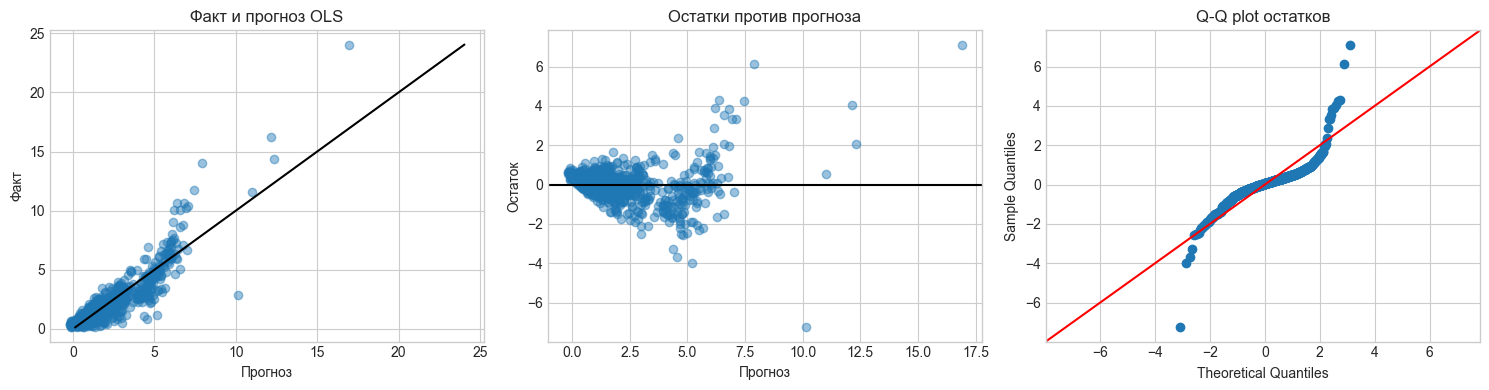

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(fitted_values, y, alpha=0.45)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], color="black")
axes[0].set_title("Факт и прогноз OLS")
axes[0].set_xlabel("Прогноз")
axes[0].set_ylabel("Факт")

axes[1].scatter(fitted_values, residuals, alpha=0.45)
axes[1].axhline(0, color="black")
axes[1].set_title("Остатки против прогноза")
axes[1].set_xlabel("Прогноз")
axes[1].set_ylabel("Остаток")

sm.qqplot(residuals, line="45", ax=axes[2])
axes[2].set_title("Q-Q plot остатков")

plt.tight_layout()

In [9]:
correlations = data.corr(numeric_only=True)[target_name].drop(target_name).sort_values(key=np.abs, ascending=False)
correlations.to_frame("correlation_with_sales")

,correlation_with_sales
growth_technological,0.8015
growth_innovation,0.7998
joint,0.7164
lab,0.6908
share_RD,0.5891
share_equipments,0.4745
climate,0.4199
compet,-0.4186
share_technology,0.3721
support,0.3583


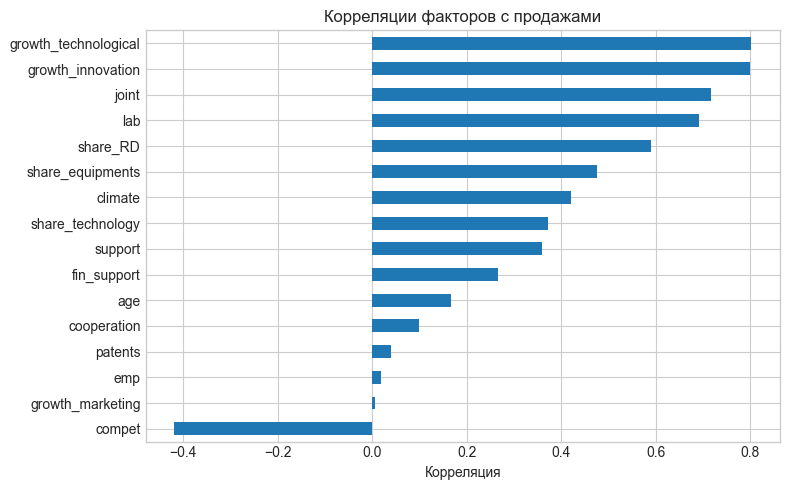

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
correlations.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Корреляции факторов с продажами")
ax.set_xlabel("Корреляция")
ax.set_ylabel("")
plt.tight_layout()

## Регуляризация и PCA

In [11]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "OLS": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 50))),
    "Lasso": make_pipeline(StandardScaler(), LassoCV(alphas=np.logspace(-4, 1, 80), cv=cv, max_iter=30000, random_state=42)),
}

comparison_rows = []
for model_name, model in models.items():
    predicted = cross_val_predict(model, x, y, cv=cv)
    comparison_rows.append(
        {
            "model": model_name,
            "cv_r2": r2_score(y, predicted),
            "cv_rmse": mean_squared_error(y, predicted) ** 0.5,
            "cv_mae": mean_absolute_error(y, predicted),
        }
    )

model_comparison = pd.DataFrame(comparison_rows).sort_values("cv_rmse")
model_comparison

,model,cv_r2,cv_rmse,cv_mae
1,Ridge,0.7891,0.9094,0.5071
2,Lasso,0.7809,0.9267,0.5151
0,OLS,0.7027,1.0795,0.5279


In [12]:
lasso_pipeline = models["Lasso"]
lasso_pipeline.fit(x, y)
lasso_model = lasso_pipeline.named_steps["lassocv"]

lasso_coefficients = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": lasso_model.coef_,
    }
).sort_values("coefficient")

lasso_coefficients

,feature,coefficient
13,fin_support,-0.1535
15,compet,-0.1211
5,cooperation,-0.0656
11,emp,-0.0237
1,growth_marketing,-0.0000
4,patents,-0.0000
12,growth_innovation,0.0000
14,age,-0.0000
10,share_technology,0.0520
3,share_equipments,0.1125


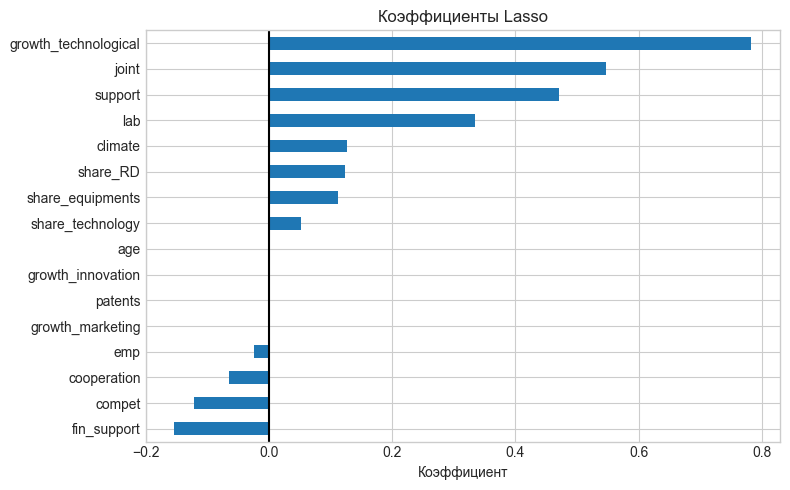

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
lasso_coefficients.plot(x="feature", y="coefficient", kind="barh", ax=ax, legend=False)
ax.axvline(0, color="black")
ax.set_title("Коэффициенты Lasso")
ax.set_xlabel("Коэффициент")
ax.set_ylabel("")
plt.tight_layout()

In [14]:
scaled_x = StandardScaler().fit_transform(x)
pca = PCA()
pca.fit(scaled_x)
explained_variance = pd.DataFrame(
    {
        "component": np.arange(1, len(pca.explained_variance_ratio_) + 1),
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_variance": np.cumsum(pca.explained_variance_ratio_),
    }
)
explained_variance

,component,explained_variance_ratio,cumulative_variance
0,1,0.2872,0.2872
1,2,0.1197,0.4070
2,3,0.0716,0.4786
3,4,0.0664,0.5450
4,5,0.0638,0.6088
5,6,0.0632,0.6720
6,7,0.0624,0.7344
7,8,0.0556,0.7900
8,9,0.0493,0.8393
9,10,0.0442,0.8835


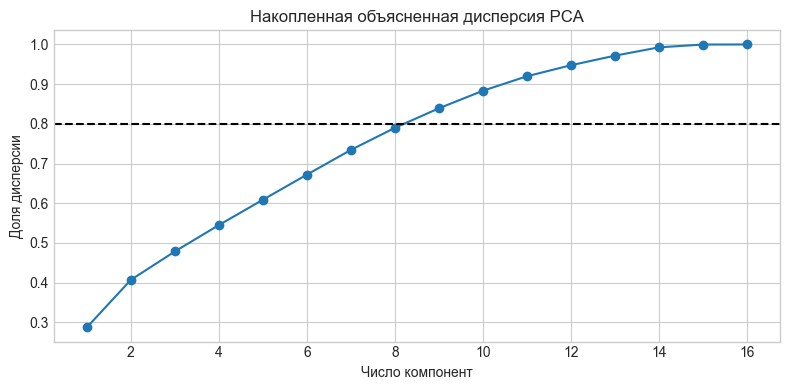

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(explained_variance["component"], explained_variance["cumulative_variance"], marker="o")
ax.axhline(0.8, color="black", linestyle="--")
ax.set_title("Накопленная объясненная дисперсия PCA")
ax.set_xlabel("Число компонент")
ax.set_ylabel("Доля дисперсии")
plt.tight_layout()

## Вывод

Модель объясняет продажи через инновационные, организационные и финансовые показатели. Регуляризация помогает отделить устойчивые эффекты от шума и мультиколлинеарности.